# PEAS description
## 3 Performance Measures
- Battery Usage
- Area Covered
- Time Taken
- It might be the case that some of these performance measures are redundant.

### Environment
- Other drones
- Obstacles of various shapes
- Wind (Probably a time-varying 2D vector field)
The environment is continuous, dynamic and stochastic.

### Actuators
- Ability to add and subtract from the force vectors the drone is generating. Or more simply, the ability to add and subtract from the drone's position and velocity vectors.
- Ability to send messages to other drones.
### Sensors
- LIDAR
- Ability to receive messages from other drones.

# Creating a Custom VMAS Environment
To make a custom VMAS environment, the following methods are necessary to implement:
- `make_world`: Defines entities that make up the world.
- `reset_world_at`: Sets the initial conditions of the entities.
- `reward`: Defines the reward of each agents after an action.
- `observation`: Defines the observations of each agent.

Optional methods are:
- `extra_render`: Can be used for rendering custom things.
- `info`: Can be used to return useful logging info.
- `done`: For defining when an environment is done. By default, the environment is done after `max_steps`.
- `pre_step`: to perform any computation that has to happen before the simulation step.
- `post_step`: to perform any computation that has to happen after the simulation step.

More information can be found at: [Setting Up a Custom VMAS Scenario](https://colab.research.google.com/github/proroklab/VectorizedMultiAgentSimulator/blob/main/notebooks/Simulation_and_training_in_VMAS_and_BenchMARL.ipynb)
![vmas_diagram](https://raw.githubusercontent.com/matteobettini/vmas-media/refs/heads/main/media/VMAS_diagram.png)

## Downloading Dependencies

In [1]:
# @title Installing main python packages
!pip install vmas wandb benchmarl imageio imageio-ffmpeg torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.9/102.9 kB 8.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.8/155.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 33.5 MB/s eta 0:00:00
ERROR: pip's dependency resolv

In [2]:
# @title Rendering dependencies
!apt-get update -qq
!apt-get install -y x11-utils python3-opengl xvfb -qq
!pip install pyvirtualdisplay torchvision "av<14" -q
import pyvirtualdisplay
display = pyvirtualdisplay.Display(visible=False, size=(1400, 900))
display.start()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package freeglut3:amd64.
(Reading database ... 125186 files and directories currently installed.)
Preparing to unpack .../0-freeglut3_2.8.1-6_amd64.deb ...
Unpacking freeglut3:amd64 (2.8.1-6) ...
Selecting previously unselected package libxcomposite1:amd64.
Preparing to unpack .../1-libxcomposite1_1%3a0.4.5-1build2_amd64.deb ...
Unpacking libxcomposite1:amd64 (1:0.4.5-1build2) ...
Selecting previously unselected package libxtst6:amd64.
Preparing to unpack .../2-libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package libxxf86dga1:amd64.
Preparing to unpack .../3-libxxf86dga1_2%3a1.1.5-0ubuntu3_amd64.deb ...
Unpacking libxxf86dga1:amd64 (2:1.1.5-0ubuntu3) ...
Selecting previously unselected package l

## Imports

In [3]:
from typing import Optional, Union, List
import random
import time
import math
import warnings
warnings.filterwarnings('ignore')

import torch
from vmas.simulator.core import Agent, Landmark, World, Box, Sphere
from vmas.simulator.scenario import BaseScenario
from vmas.simulator.utils import Color
from vmas.simulator.sensors import Lidar
from vmas import make_env
from vmas.simulator.utils import ScenarioUtils
from vmas.simulator import rendering
from vmas.simulator.rendering import Geom
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [4]:
import imageio
import torchvision.io


def _patched_write_video(filename, video_array, fps, **kwargs):
    # Ensure video_array is uint8 numpy array in (T, H, W, C) format
    if isinstance(video_array, torch.Tensor):
        video_array = video_array.cpu().numpy()
    if video_array.dtype != "uint8":
        video_array = (video_array * 255).astype("uint8")

    imageio.mimsave(filename, video_array, fps=fps, format="FFMPEG", macro_block_size=None)


# Replace the deprecated/broken function
torchvision.io.write_video = _patched_write_video

## Scenario Declaration

In [5]:
class WindNavScenario(BaseScenario):

    def make_world(self, batch_dim: int, device: torch.device, **kwargs) -> World:
        raise NotImplementedError()

    def reset_world_at(self, env_index: Optional[int] = None) -> None:
        raise NotImplementedError()

    # Maybe this should not be part of the class?
    # It is used to calculate the wind force at a position(s)
    def get_wind_force(self, pos: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError()

    def process_action(self, agent: Agent) -> None:
        raise NotImplementedError()

    def observation(self, agent: Agent) -> torch.Tensor:
        raise NotImplementedError()

    def done(self, agent: Agent) -> torch.Tensor:
        raise NotImplementedError()

    def reward(self, agent: Agent) -> torch.Tensor:
        raise NotImplementedError()

    def extra_render(self, env_index: int = 0) -> List[Geom]:
        raise NotImplementedError()

## Scenario Method Implementations

In [6]:
def make_world(self, batch_dim: int, device: torch.device, **kwargs) -> World:

    self.num_agents = kwargs.pop("num_agents", 1)
    self.agent_radius = kwargs.pop("agent_radius", 0.05)
    self.lidar_range = kwargs.pop("lidar_range", 0.3)  # Range of the LIDAR sensor
    self.n_lidar_rays = kwargs.pop(
        "n_lidar_rays", 20
    )  # Number of LIDAR rays around the agent, each ray gives an observation between 0 and lidar_range

    self.wind_present = kwargs.pop("wind_present", False)
    self.render_wind = kwargs.pop("render_wind", False)

    self.battery_constraint = kwargs.pop("battery_constraint", False)
    self.max_battery = kwargs.pop("max_battery", 100)
    self.battery_decay_coef = kwargs.pop("battery_decay_coef", 10)


    self.num_obstacles = kwargs.pop("num_obstacles", 10)

    # X-coordinate limit for entities spawning
    self.world_spawning_x = kwargs.pop("world_spawning_x", 1)
    # Y-coordinate limit for entities spawning
    self.world_spawning_y = kwargs.pop("world_spawning_y", 1)

    self.min_distance_between_entities = (
        self.agent_radius * 2 + 0.05
    )  # Minimum distance between entities at spawning time
    self.min_collision_distance = (
        0.005  # Minimum distance between entities for collision trigger
    )

    ScenarioUtils.check_kwargs_consumed(kwargs) # Warn if not all kwargs have been consumed

    world = World(
        dim_c=0, # Number of communication channels if any
        substeps=1,
        batch_dim=batch_dim,
        device=device,
        **kwargs
    )
    # initialize goal(s)
    # Single goal for now
    goal = Landmark(
        name="goal",
        collide=False,
        movable=False,
        shape=Sphere(radius=0.05),
        color=Color.GREEN,
    )
    world.add_landmark(goal)

    # initialize agents
    for i in range(self.num_agents):
        sensors = [
            Lidar(
                    world,
                    n_rays=self.n_lidar_rays,
                    max_range=self.lidar_range,
                    entity_filter=lambda e: e.collide,
                    angle_start=0.0,  # LIDAR angular ranges (we sense 360 degrees)
                    angle_end=2
                    * torch.pi,  # LIDAR angular ranges (we sense 360 degrees)
                    render=True,
                    render_color=Color.BLACK
                )
            ]  # Agent LIDAR sensor

        agent = Agent(
            name=f"agent_{i}",
            collide=True,
            sensors=sensors, # give agent the sensors
            render_action=True,
            shape=Sphere(radius=self.agent_radius),
            color=Color.BLUE,
            max_speed=1.0
        )
        world.add_agent(agent)
        agent.goal = goal
        agent.state.battery_level = torch.zeros(batch_dim, device=device, dtype=torch.float32)

    # configure rectangular obstacles
    self.obstacles = []
    for i in range(self.num_obstacles):
        obstacle = Landmark(
            name=f"obstacle_{i}",
            collide=True,
            movable=False,
            shape=Box(length=random.random(), width=random.random()),
            color=Color.RED,
        )
        world.add_landmark(obstacle)
        self.obstacles.append(obstacle)

    return world

WindNavScenario.make_world = make_world

In [7]:
def reset_world_at(self, env_index: Optional[int] = None) -> None:
    """Resets the world at the specified env_index."""
    ScenarioUtils.spawn_entities_randomly(
        self.world.agents + self.world.landmarks,
        self.world,
        env_index,
        self.min_distance_between_entities,
        x_bounds=(-self.world_spawning_x, self.world_spawning_x),
        y_bounds=(-self.world_spawning_y, self.world_spawning_y),
    )

    # Reset battery level
    for agent in self.world.agents:
        if env_index is None:
            agent.state.battery_level[:] = self.max_battery
        else:
            agent.state.battery_level[env_index] = self.max_battery
            
    # Sync prev_goal_dist to current spawn positions on environment reset
    for agent in self.world.agents:
        dist = torch.linalg.vector_norm(
            agent.state.pos - agent.goal.state.pos, dim=-1
        )
        if hasattr(agent, "prev_goal_dist"):
            if env_index is None:
                agent.prev_goal_dist = dist.clone()
            else:
                agent.prev_goal_dist[env_index] = dist[env_index].clone()

    for agent in self.world.agents:
            if not hasattr(agent, "stuck_steps"):
                agent.stuck_steps = torch.zeros(
                    self.world.batch_dim, device=self.world.device
                )
            agent.stuck_steps[env_index] = 0.0


WindNavScenario.reset_world_at = reset_world_at

In [8]:
def get_wind_force(self, pos: torch.Tensor) -> torch.Tensor:
    """
    Calculates 2D vector field force based on absolute global coordinates
    Args:
        pos: Tensor of shape (n_env, 2) containing coordinates
    Returns:
        force: Tensor of shape (n_env, 2) acting on agents
    """

    x = pos[..., 0]
    y = pos[..., 1]

    wind_x = torch.full_like(x, 0.05)
    wind_y = 0.1 * torch.sin(x * torch.pi)

    return torch.stack([wind_x, wind_y], dim=-1)

WindNavScenario.get_wind_force = get_wind_force

In [9]:
def process_action(self, agent: Agent) -> None:
    """
    This hook executes right before the physics step.
    We use it to apply our background wind vector field to all movable agents.
    """
    # Calculate new battery level
    action_magnitude = torch.linalg.vector_norm(agent.action.u, dim=1)
    agent.state.battery_level = torch.clamp(agent.state.battery_level - self.battery_decay_coef*action_magnitude, min=0.0)

    # set force equal to 0 for agents whose batteries are depleted
    depleted = (self.battery_constraint and agent.state.battery_level <= 0)
    agent.action.u[depleted] = 0

    # add wind force
    agent.action.u[~depleted] += self.get_wind_force(agent.state.pos[~depleted]) if self.wind_present else 0

WindNavScenario.process_action = process_action

In [10]:
def observation(self, agent: Agent) -> torch.Tensor:
    obs = {
        "obs": torch.cat(
            [
                agent.state.pos - agent.goal.state.pos
            ]  # Relative position to goal (fundamental)
            + [
                agent.state.pos - obstacle.state.pos for obstacle in self.obstacles
            ]  # Relative position to obstacles (fundamental)
            + [
                sensor._max_range - sensor.measure() for sensor in agent.sensors
            ],  # LIDAR to avoid other agents
            dim=-1,
        ),
        "pos": agent.state.pos,
        "vel": agent.state.vel,
    }

    return obs

WindNavScenario.observation = observation

In [11]:
def reward(self, agent: Agent) -> torch.Tensor:
    distance_to_goal = torch.linalg.vector_norm(
        agent.state.pos - agent.goal.state.pos, dim=-1
    )

    if not hasattr(agent, "prev_goal_dist"):
        agent.prev_goal_dist = distance_to_goal.clone()
        agent.stuck_steps = torch.zeros(
            self.world.batch_dim, device=self.world.device
        )

    # scaled goal progress
    progress_weight = 10.0
    rew = progress_weight * (agent.prev_goal_dist - distance_to_goal)
    agent.prev_goal_dist = distance_to_goal.clone()

    # Wall Sliding
    margin = 0.35
    for landmark in self.world.landmarks:
        if landmark.collide and landmark is not agent.goal:
            rel_obs_pos = landmark.state.pos - agent.state.pos
            dist_to_obs = torch.linalg.vector_norm(rel_obs_pos, dim=-1)
            obs_radius = getattr(landmark.shape, "radius", 0.0)
            surface_dist = dist_to_obs - (agent.shape.radius + obs_radius)

            # Continuous clearance penalty
            proximity = torch.clamp(margin - surface_dist, min=0.0)
            rew -= 2.0 * proximity

            # penalize velocity directed into the obstacle surface
            obs_dir = rel_obs_pos / (dist_to_obs.unsqueeze(-1) + 1e-6)
            normal_vel = torch.sum(agent.state.vel * obs_dir, dim=-1)
            rew -= 1.5 * torch.clamp(normal_vel, min=0.0) * (proximity > 0)

            # hard overlap penalty
            collided = self.world.is_overlapping(agent, landmark)
            rew -= 2.0 * collided.float()

    # agent-agent collision penalty
    for other in self.world.agents:
        if other is not agent:
            collided = self.world.is_overlapping(agent, other)
            rew -= 0.5 * collided.float()

    # increasing penalty for agents that remain in corners
    goal_radius = getattr(agent.goal.shape, "radius", 0.0)
    agent_reached = distance_to_goal < (agent.shape.radius + goal_radius)
    speed = torch.linalg.vector_norm(agent.state.vel, dim=-1)

    is_stuck = (speed < 0.08) & (~agent_reached)
    agent.stuck_steps = torch.where(
        is_stuck, agent.stuck_steps + 1.0, torch.zeros_like(agent.stuck_steps)
    )
    rew -= 0.01 * torch.pow(agent.stuck_steps, 1.5)

    # reward for reaching goal for individual agent
    rew += 5.0 * agent_reached.float()

    # reward given when all agents reach the goal
    all_reached = torch.ones(
        self.world.batch_dim, device=self.world.device, dtype=torch.bool
    )
    for a in self.world.agents:
        d = torch.linalg.vector_norm(a.state.pos - a.goal.state.pos, dim=-1)
        r = getattr(a.goal.shape, "radius", 0.0)
        all_reached &= d < (a.shape.radius + r)

    rew += 50.0 * all_reached.float()

    return rew
    
WindNavScenario.reward = reward

In [12]:
def done(self) -> torch.Tensor:
    device = self.world.device
    batch_dim = self.world.batch_dim
    any_reached = torch.zeros(batch_dim, device=device, dtype=torch.bool)

    all_reached = True
    for a in self.world.agents:
        goal_radius = getattr(a.goal.shape, "radius", 0.0)
        threshold = a.shape.radius + goal_radius

        dist_to_goal = torch.linalg.vector_norm(
            a.state.pos - a.goal.state.pos, dim=-1
        )
        all_reached &= dist_to_goal < threshold

    return all_reached


WindNavScenario.done = done

In [13]:
def extra_render(self, env_index: int = 0) -> List[Geom]:
    """
    1. Draws the wind vector field
    """
    geoms = []
    if self.render_wind:
        x = torch.linspace(-2, 2, 20)
        y = torch.linspace(-2, 2, 20)

        grid_x, grid_y = torch.meshgrid(x, y, indexing="ij")
        grid_pos = torch.stack([grid_x, grid_y], dim=-1)
        grid_wind = get_wind_force(self, grid_pos)

        # 1. Calculate the magnitude of each wind vector
        # keepdim=True preserves the last dimension so we can divide cleanly
        wind_magnitude = torch.linalg.vector_norm(grid_wind, dim=-1, keepdim=True)

        # 2. Normalize magnitude to a [0, 1] range for color mapping
        max_magnitude = wind_magnitude.max()
        min_magnitude = wind_magnitude.min()

        # Clamp to [0, 1] to avoid color overflow bugs
        normalized_mag = torch.clamp(
            (wind_magnitude - min_magnitude) / (max_magnitude - min_magnitude + 1e-6),
            0.0,
            1.0
        )

        # 2. Add a tiny epsilon to prevent division-by-zero if wind is ever exactly 0
        eps = 1e-6

        # 3. Define how long you want the lines to look on screen
        desired_length = 0.1

        # 4. Normalize the vectors and scale them to your desired length
        normalized_wind = (grid_wind / (wind_magnitude + eps)) * desired_length

        # 5. Calculate end points using the normalized wind field
        end_grid = grid_pos + normalized_wind
        start_x = grid_pos[..., 0]
        start_y = grid_pos[..., 1]
        end_x = end_grid[..., 0]
        end_y = end_grid[..., 1]

        for i in range(grid_x.shape[0]):
            for j in range(grid_x.shape[1]):
                line = rendering.Line((start_x[i, j].item(), start_y[i, j].item()), (end_x[i, j].item(), end_y[i, j].item()), width=2)


                intensity = normalized_mag[i, j].item()

                # Blue-to-Red Colormap Gradient:
                # Low magnitude = Pure Blue (0, 0, 1)
                # High magnitude = Pure Red (1, 0, 0)
                r = intensity
                g = 0.0
                b = 1.0 - intensity
                alpha = 0.8  # Kept slightly transparent so background remains clean

                line.set_color(r, g, b, alpha)
                geoms.append(line)
    return geoms

WindNavScenario.extra_render = extra_render

## Creating and Running the Environment

In [14]:
# This code was provided by one of the collab notebooks given in VMAS github
# https://colab.research.google.com/github/proroklab/VectorizedMultiAgentSimulator/blob/main/notebooks/VMAS_Use_vmas_environment.ipynb
def use_vmas_env(
        render: bool,
        num_envs: int,
        n_steps: int,
        device: str,
        scenario: Union[str, BaseScenario],
        continuous_actions: bool,
        random_action: bool,
        verbose=True,
        extra_render_func=None,
        **kwargs,
    ):

    scenario_name = scenario if isinstance(scenario,str) else scenario.__class__.__name__

    env = make_env(
        scenario=scenario,
        num_envs=num_envs,
        device=device,
        continuous_actions=continuous_actions,
        seed=420,
        **kwargs
    )

    frame_list = []
    init_time = time.time()

    reward_history = []

    for step in range(1, n_steps+1):
        if verbose:
            print(f"Step {step}")

        actions = []
        for i, agent in enumerate(env.agents):
            # TODO: decide action using MARL algorithm
            if random_action:
                action = env.get_random_action(agent)
                actions.append(action)

        obs, rews, dones, info = env.step(actions)
        reward_history.append(rews[0][0])

        if render:
            frame = env.render(
                mode="rgb_array",
                agent_index_focus=None # # Can give the camera an agent index to focus on
            )
            frame_list.append(frame)

    total_time = time.time() - init_time
    print(
        f"It took: {total_time:.2f}s for {n_steps} steps of {num_envs} parallel environments on device {device} "
        f"for {scenario_name} scenario."
    )

    if render:
        # Source - https://stackoverflow.com/a/35943809
        import imageio
        imageio.mimsave(f'{scenario_name}.gif', frame_list, loop=0)

    return reward_history

It took: 16.96s for 100 steps of 4 parallel environments on device cpu for WindNavScenario scenario.


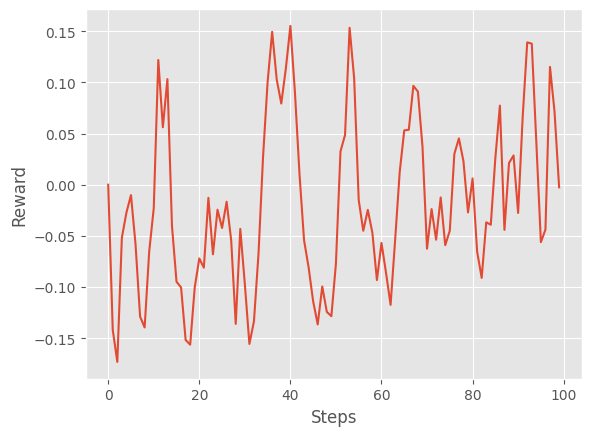

In [15]:
wind_scenario = WindNavScenario()

scenario_name = wind_scenario.__class__.__name__
reward_history = use_vmas_env(
    render=True,
    num_envs=4,
    num_agents=10,
    n_steps=100,
    num_obstacles=10,
    device="cpu",
    scenario=wind_scenario,
    continuous_actions=True,
    random_action=True,
    extra_render_func=extra_render,
    verbose=False,
    world_spawning_x=2,
    world_spawning_y=2,
)

x = [i for i in range(len(reward_history))]
y = reward_history
plt.plot(x, y)
plt.xlabel("Steps")
plt.ylabel("Reward")
plt.show()

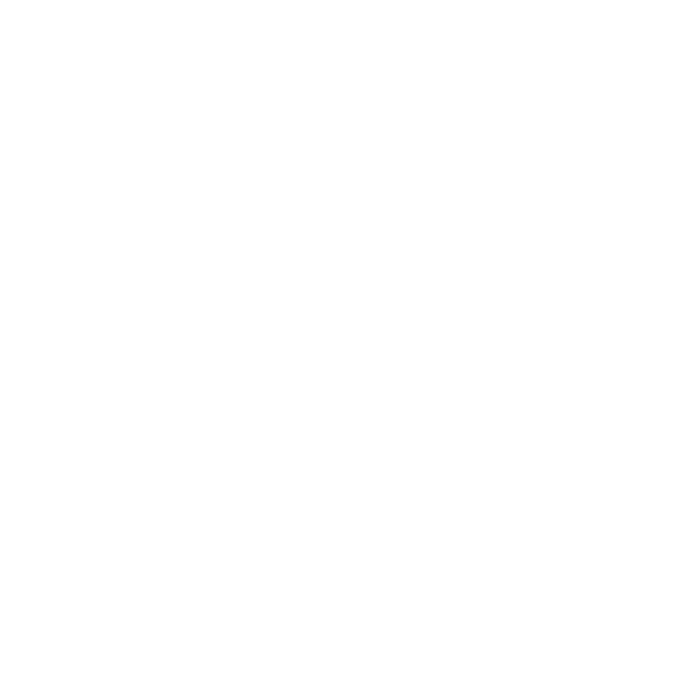

In [16]:
from IPython.display import Image
Image(f'{scenario_name}.gif')

# Training Using **MAPPO**

Here are the tasks that will be performed:
1. Import and configure **MAPPO**. (Task Config, Algo Config, Model Config and Experiment Config)
2. Train without GNN first, and then use GNN.
3. Wandb logging
4. Improve reward function
5. Add penalty for obstacle or agent collision.

## Imports

In [17]:
import copy
from typing import Callable, Optional

import torch
import vmas
from benchmarl.environments import VmasTask
from benchmarl.utils import DEVICE_TYPING
from torchrl.envs import VmasEnv, EnvBase
from benchmarl.experiment import Experiment, ExperimentConfig
from benchmarl.algorithms import MappoConfig
from benchmarl.models.mlp import MlpConfig

## Configs

In [18]:
def get_env_fun(
        self,
        num_envs: int,
        continuous_actions: bool,
        seed: Optional[int],
        device: DEVICE_TYPING
) -> Callable[[], EnvBase]:
    config = copy.deepcopy(self.config)
    if hasattr(self, "name") and self.name == "NAVIGATION" or (self is VmasTask.NAVIGATION):
        scenario = WindNavScenario()
    else:
        scenario = self.name.lower()

    return lambda: VmasEnv(
        scenario=scenario,
        num_envs=num_envs,
        continuous_actions=continuous_actions,
        seed=seed,
        device=device,
        categorical_actions=False,
        clamp_actions=True,
        **config,
    )

try:
    from benchmarl.environments import VmasClass
    VmasClass.get_env_fun = get_env_fun
except ImportError:
    VmasTask.get_env_fun = get_env_fun

In [19]:
# @title Devices
train_device = "cuda" # @param {"type":"string"}
vmas_device = "cuda" # @param {"type":"string"}

### Experiment Config

In [20]:
experiment_config = ExperimentConfig.get_from_yaml()

# override devices
experiment_config.train_device = train_device
experiment_config.sampling_device = vmas_device

experiment_config.max_n_frames = 5_000_000 # number of frames before training ends
experiment_config.gamma = 0.99
experiment_config.on_policy_collected_frames_per_batch = 60_000 # number of frames collected each iteration
experiment_config.on_policy_n_envs_per_worker = 600 # Number of vmas vectorized environments (each will collect 100 steps, see max_steps in task_config -> 600 * 100 = 60,000)
experiment_config.on_policy_n_minibatch_iters = 45
experiment_config.on_policy_minibatch_size = 4096
experiment_config.evaluation = True
experiment_config.render = True
experiment_config.share_policy_params = True # all agents share the same network
experiment_config.evaluation_interval = 120_000 # interval in terms of frames, will evaluate every 120,000 / 60,000 = 2 iterations.
experiment_config.evaluation_episodes = 200 # numbe of vmas environments used in evaluation
experiment_config.loggers = ["csv"]

### Task Config

In [21]:
task = VmasTask.NAVIGATION.get_from_yaml()

task.config = {
    "max_steps": 200,
    "num_agents": 6,
    "num_obstacles": 6,
}

### Algorithm Config

In [22]:
algorithm_config = MappoConfig(
    share_param_critic=True,
    clip_epsilon=0.2,
    entropy_coef=0.001,
    critic_coef=1,
    loss_critic_type="l2",
    lmbda=0.9,
    scale_mapping="biased_softplus_1.0",
    use_tanh_normal=True,
    minibatch_advantage=False,
)

### Model Config

In [23]:
model_config = MlpConfig(
    num_cells=[256, 256], # two layers with 256 neurons each
    layer_class=torch.nn.Linear,
    activation_class=torch.nn.Tanh
)

critic_model_config = MlpConfig.get_from_yaml()

## Training

In [24]:
# experiment_config.max_n_frames = 100000
# experiment_config.on_policy_n_envs_per_worker = 2 # Remove this line for full training
# experiment_config.on_policy_n_minibatch_iters = 1 # Remove this line for full training

experiment = Experiment(
    task=task,
    algorithm_config=algorithm_config,
    model_config=model_config,
    critic_model_config=critic_model_config,
    seed=0,
    config=experiment_config
)

experiment.run()

/usr/local/lib/python3.12/dist-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
  0%|          | 0/84 [00:00<?, ?it/s]

2026-08-16 11:51:04,304 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([60000]) shape [END]


mean return = -31.5556583404541: 100%|██████████| 84/84 [48:08<00:00, 34.39s/it]


In [25]:
 experiment.evaluate()

Evaluation results logged to loggers=['csv'] and to a json file in the experiment folder.
